In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\cleaned_data.csv")

# train/test split
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
test_month = df["CloseDate"].dt.to_period("M").max()

train_df = df[df["CloseDate"].dt.to_period("M") != test_month].copy()
test_df  = df[df["CloseDate"].dt.to_period("M") == test_month].copy()

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")

Train rows: 49703
Test rows:  12024


In [6]:
# Features to use for modeling
# Note: FireplacesTotal and TaxAnnualAmount removed because entirely empty in the dataset
feature_cols = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "GarageSpaces",
    "DaysOnMarket", "Latitude", "Longitude",
    "AssociationFee",
    "AttachedGarageYN", "FireplaceYN", "PoolPrivateYN",
    "ViewYN", "NewConstructionYN",
    "City_encoded", "PostalCode_encoded",
    "CountyOrParish_encoded", "HighSchoolDistrict_encoded"
]

X_train = train_df[feature_cols]
y_train = train_df["ClosePrice"]

X_test = test_df[feature_cols]
y_test = test_df["ClosePrice"]

print(f"Features used: {len(feature_cols)}")
print("NaN check:", X_train.isnull().sum().sum(), "missing values")

Features used: 19
NaN check: 0 missing values


In [7]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate R²
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=" * 40)
print("BASELINE MODEL RESULTS")
print("=" * 40)
print(f"R² Score:               {r2:.4f}")
print(f"Mean Absolute Error:    ${mae:,.0f}")
print("=" * 40)

BASELINE MODEL RESULTS
R² Score:               0.2995
Mean Absolute Error:    $571,171


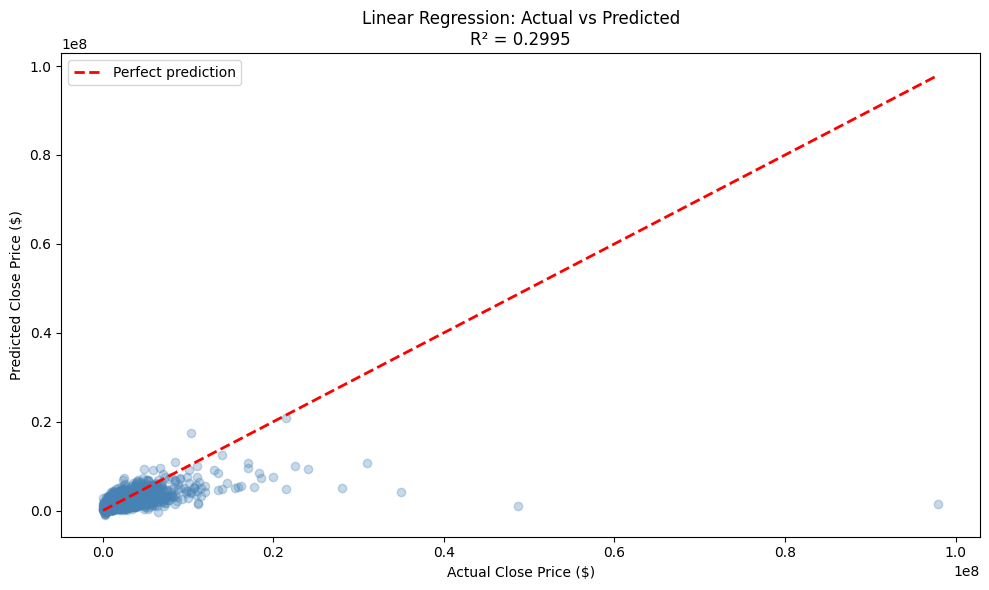

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(f"Linear Regression: Actual vs Predicted\nR² = {r2:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Save results for comparison later
results = pd.DataFrame({
    "Model": ["Linear Regression (Baseline)"],
    "R2_Score": [round(r2, 4)],
    "MAE": [round(mae, 0)],
    "Train_Months": [train_df["CloseDate"].dt.to_period("M").nunique()],
    "Test_Month": [str(test_month)]
})

print(results)


                          Model  R2_Score       MAE  Train_Months Test_Month
0  Linear Regression (Baseline)    0.2995  571171.0             5    2026-05


In [11]:

# Save to CSV
results.to_csv(
    r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\model_results.csv",
    index=False
)
print("\nResults saved to model_results.csv")


Results saved to model_results.csv
